In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import moment
import seaborn as sns
from pathlib import Path
import tqdm
import os
import warnings
warnings.filterwarnings('ignore')

#%mldev import

/Users/andrey/MIPT_projects/2023-project-119


In [2]:
print("Staprting Decreasing_Moments.ipynb ...")
#%mldev start

Staprting Decreasing_Moments.ipynb ...


```yaml

#%mldev nb_context

Decreasing_Moments:
  - import
  - start
  - experiment_mode
  - paths
  - rc
  - plot_l1_k_moments
  - plot_k_moments
  - sliding_window_setup_sgd_synthetic
  - sliding_window_setup_sgd_friedman
  - sampling_update_setup_sgd_synthetic
  - sampling_update_setup_sgd_friedman
```

In [3]:
experiment_mode = 'mldev'
#%mldev experiment_mode

In [4]:
# run this cell if you are in Jupyter and not running the notebook with mldev
experiment_mode = 'jupyter'

In [5]:
path_loop = os.getenv("MLDEV_DELTA_LOOP_PATH", default="results/hidden-loop_delta")
path_sample = os.getenv("MLDEV_DELTA_SAMPLE_PATH", default="results/hidden-sample_delta")
save_path = os.getenv("MLDEV_SAVEFIGURES_PATH", default="figures")
os.makedirs(save_path, exist_ok=True)
#%mldev paths

In [6]:
plt.rc('axes', titlesize=25, titleweight='bold') #fontsize of the title
plt.rc('axes', labelsize=20) #fontsize of the x and y labels
plt.rc('xtick', labelsize=20) #fontsize of the x tick labels
plt.rc('ytick', labelsize=20) #fontsize of the y tick labels
plt.rc('legend', fontsize=25) #fontsize of the legend
plt.rc('figure', figsize=(12, 8)) # figure size
#%mldev rc

In [10]:
# for sliding window setup
def plot_l1_k_moments(path, N=500, usage=1, adherence=0, run_times=10, 
                      model_name='sgd_model_50', dataset_name='synthetic',
                      experiment_name='sw', experiment_mode='jupyter'):
    directory = Path(f"{path}/{adherence}-{usage}/{dataset_name}/{model_name}/0")
    steps = []
    for file in directory.iterdir():
        if file.name != '.DS_Store':
            steps.append(int(file.name.split('_')[-1].split('.')[0]))
    steps = sorted(steps)
    l1_norm_list = []
    for trial in tqdm.trange(run_times):
        for step in steps:
            directory = Path(f"{path}/{adherence}-{usage}/{dataset_name}/{model_name}/{trial}")
            data = pd.read_csv(f"{directory}/dev_step_{step}.csv")
            data_hist = data['y'] - data['y_pred']
            l1_norm = 0
            for k in range(N+1):
                try:
                    l1_norm += moment(data_hist, moment=k)
                except OverflowError:
                    print(f'OverflowError on moment={k}')
                    break
            l1_norm_list.append(l1_norm)
    
    plt.title(f"usage={usage}, adherence={adherence}")

    plt.xlabel("step t")
    plt.ylabel(r"$\ln(1 + ||\nu_k^t||_1), N = %i$" % N)

    l1_norm_list = np.array(l1_norm_list)
    sns.lineplot(x=steps*run_times, y=np.log(1 + l1_norm_list), 
                 label = r"$\ln(1 + ||\nu_k^t||_1)$", color='blue', marker=None)
    plt.plot(steps, [0]*len(steps), '--', 
             label = r"0, limit of $\ln(1 + ||\nu_k^t||_1)$", color="red")

    plt.legend()
    plt.grid()
    plt.tight_layout()
    if experiment_mode == 'jupyter':
        plt.show()
    elif experiment_mode == 'mldev':
        plt.savefig(f"{save_path}/k_mom_{experiment_name}_{dataset_name}_{model_name}_{usage}_{adherence}.png")
        plt.close()
    else:
        raise ValueError(f"Wrong experiment mode {experiment_mode}!")
#%mldev plot_l1_k_moments

In [30]:
def plot_k_moments(path, N, usage=1.0, adherence=0.0, run_times=10, 
                   model_name='sgd_model_50', dataset_name='synthetic', 
                   t_end=2000, experiment_name='su', experiment_mode='jupyter'):
    directory = Path(f"{path}/{adherence}-{usage}/{dataset_name}/{model_name}/0")
    steps = []
    for file in directory.iterdir():
        if file.name != '.DS_Store':
            steps.append(int(file.name.split('_')[-1].split('.')[0]))
    steps = sorted(steps)[:t_end]
    moments = {} 
    for k in range(1, N+1):
        moments[k] = []
    for trial in tqdm.trange(run_times):
        for step in steps:
            directory = Path(f"{path}/{adherence}-{usage}/{dataset_name}/{model_name}/{trial}")
            data = pd.read_csv(f"{directory}/dev_step_{step}.csv")
            data_hist = data['y'] - data['y_pred']
            for k in moments.keys():
                moment_t = moment(data_hist, moment=k)
                moments[k].append(moment_t)
    
    colors = ['green', 'blue', 'orange', 'purple', 'cyan', 'black']
    plt.title(f"usage={usage}, adherence={adherence}")
    plt.xlabel(r"step $t$")
    plt.ylabel(r"$\ln(1 + |\nu_k^t|)$")

    for k, moment_t, color in zip(moments.keys(), moments.values(), colors):
        #moment_t = np.array(moment_t)
        sns.lineplot(x=steps*run_times, y=np.log(np.abs(moment_t) + 1), label = r"$k = %i$" % k,
                     color=color, marker=None)

    plt.plot(steps, [0]*len(steps), '--', label = r"0, limit of $\ln(1 + |\nu_k^t|)$",
            color="red")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    if experiment_mode == 'jupyter':
        plt.show()
    elif experiment_mode == 'mldev':
        plt.savefig(f"{save_path}/k_mom_{experiment_name}_{dataset_name}_{model_name}_{usage}_{adherence}.png")
        plt.close()
    else:
        raise ValueError(f"Wrong experiment mode {experiment_mode}!")
#%mldev plot_k_moments

## Sliding window setup

100%|██████████| 10/10 [00:47<00:00,  4.74s/it]


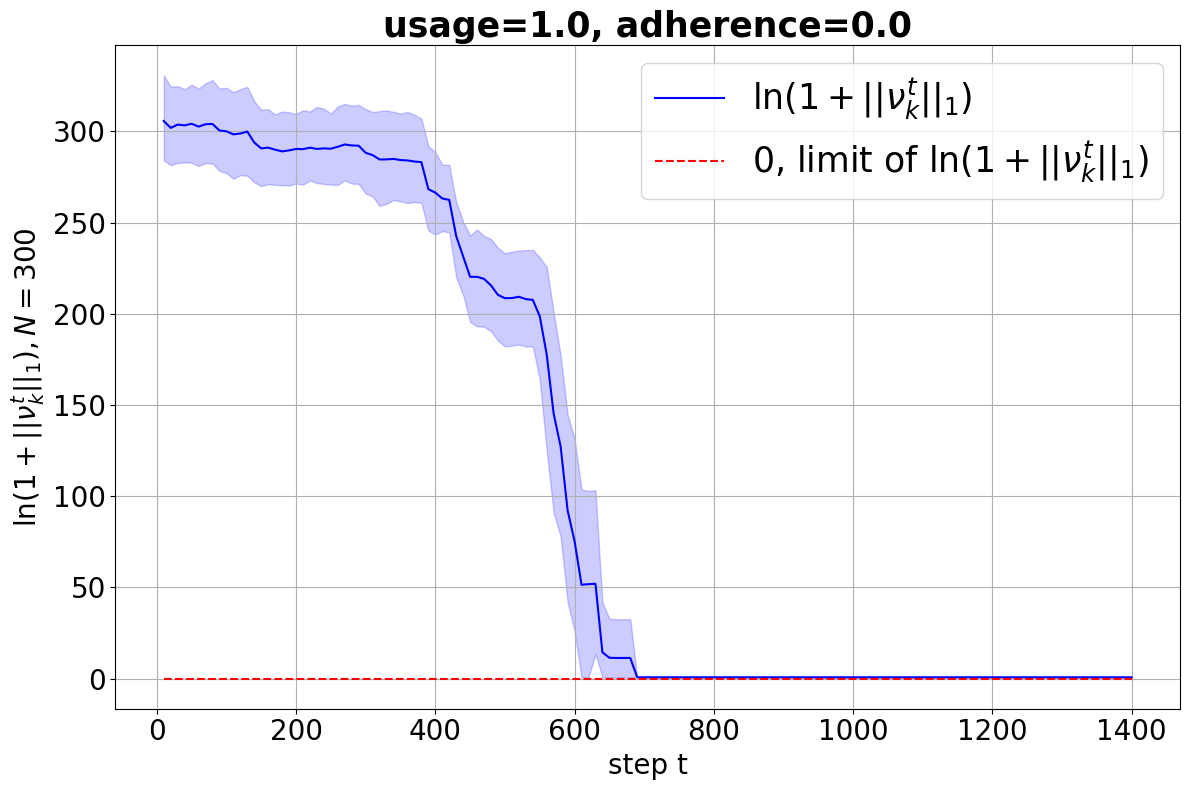

In [24]:
model_name = 'sgd_model_50'
dataset_name = 'synthetic'
plot_l1_k_moments(path=path_loop, N=300, usage=1.0, adherence=0.0, run_times=10,
                  experiment_name='sw', model_name=model_name, dataset_name=dataset_name,
                  experiment_mode=experiment_mode)
#%mldev sliding_window_setup_sgd_synthetic

100%|██████████| 10/10 [00:46<00:00,  4.65s/it]


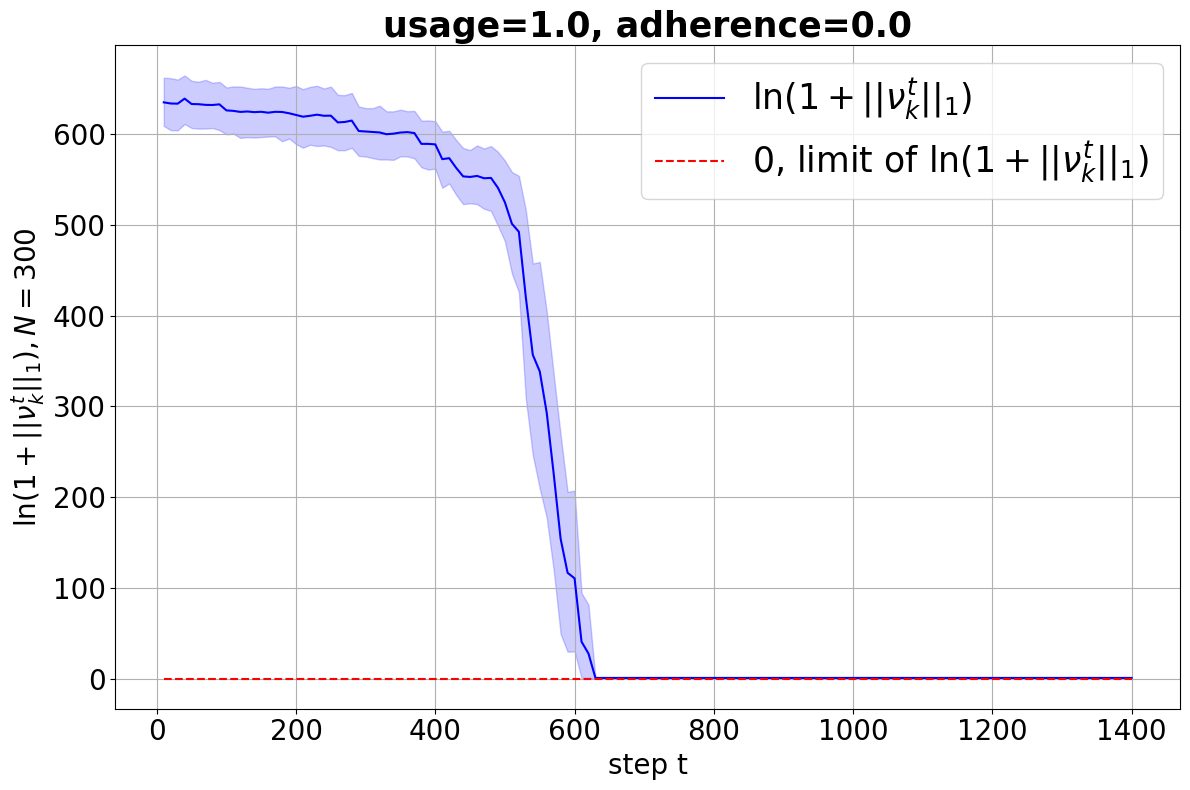

In [25]:
model_name = 'sgd_model_50'
dataset_name = 'friedman'
plot_l1_k_moments(path=path_loop, N=300, usage=1.0, adherence=0.0, run_times=10,
                  experiment_name='sw', model_name=model_name, dataset_name=dataset_name,
                  experiment_mode=experiment_mode)
#%mldev sliding_window_setup_sgd_friedman

## Sampling update setup 

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:27<00:00,  2.75s/it]


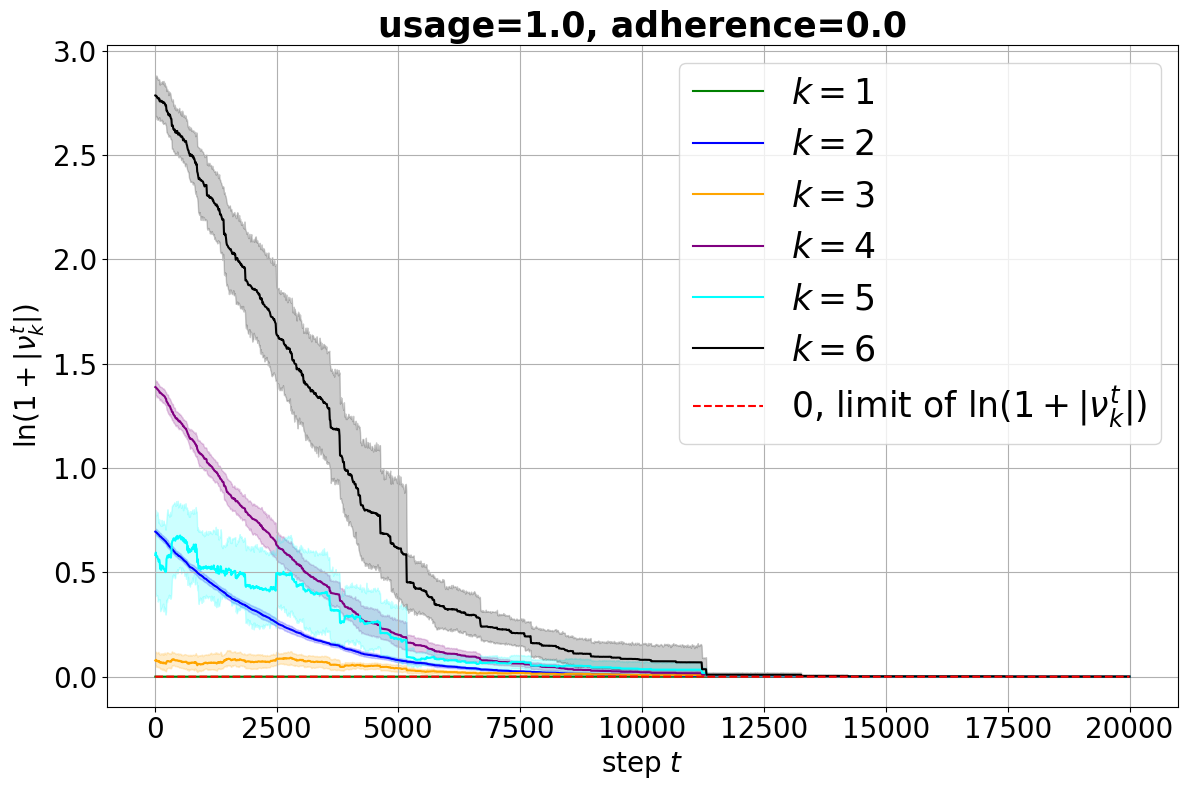

In [31]:
model_name = 'sgd_model_50'
dataset_name = 'synthetic'
plot_k_moments(path=path_sample, N=6, usage=1.0, adherence=0.0, run_times=10,
               experiment_name='su', t_end=2000,
               model_name=model_name, dataset_name=dataset_name,
               experiment_mode=experiment_mode)
#%mldev sampling_update_setup_sgd_synthetic

100%|██████████| 10/10 [00:28<00:00,  2.80s/it]


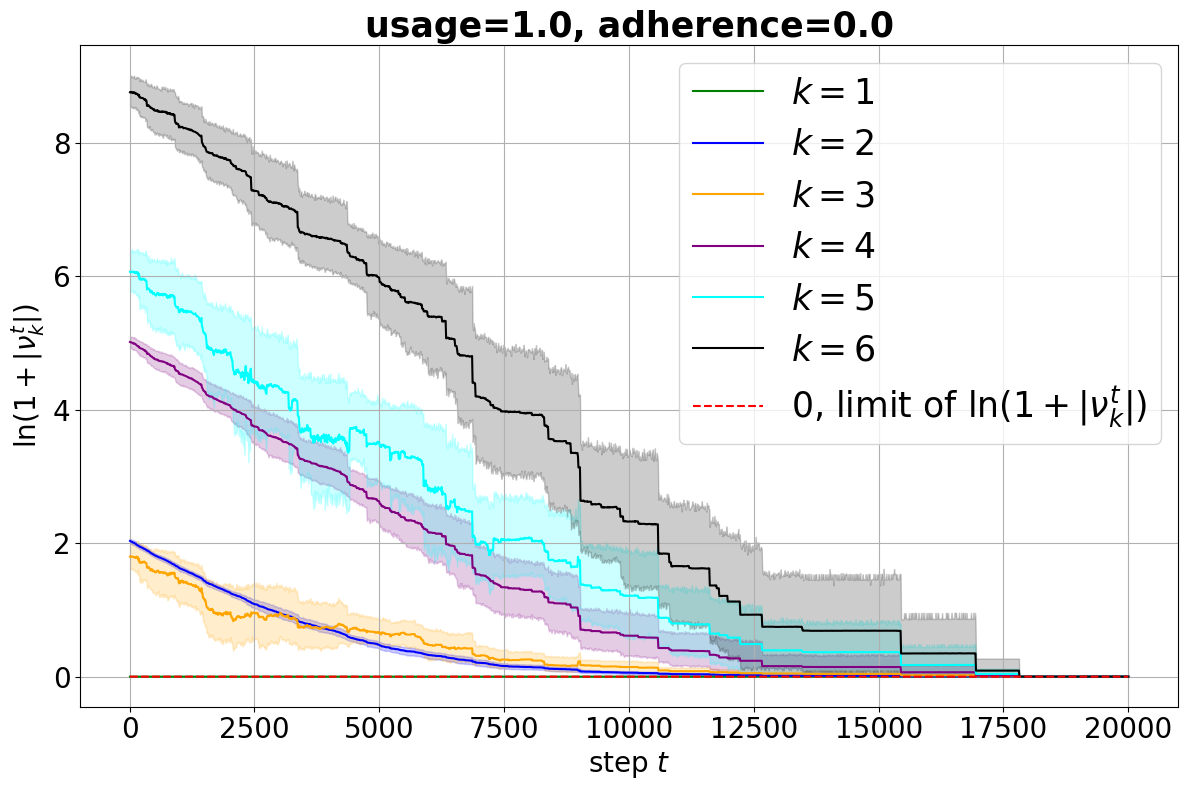

In [32]:
model_name = 'sgd_model_50'
dataset_name = 'friedman'
plot_k_moments(path=path_sample, N=6, usage=1.0, adherence=0.0, run_times=10,
               experiment_name='su', t_end=2000,
               model_name=model_name, dataset_name=dataset_name,
               experiment_mode=experiment_mode)
#%mldev sampling_update_setup_sgd_friedman